# EpiCoV 2020

- Number of sequences: `200,524`
- Collection dates: 1 Jan 20 to 6 Jul 20

In [1]:
# General
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Custom helpers
from utils import (standardize_country_name, get_continent, choropleth_continent,
choropleth_world, map_age_to_group, col_fillna, plot_dominant_choropleth, inclusion_exclusion,
standardize_vaccine_status, map_pat_status)

import warnings
warnings.filterwarnings("ignore")

In [2]:
YEAR = "2020"
DATA_PATH = os.path.expanduser(f"~/gcs-data/Full_data/epicov_{YEAR}_200k.csv")
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.expanduser(f"~/gcs-data/Full_data/epicov_{YEAR}_200k.parquet")
PLOTS_PATH = f"Nov25_plots/epicov_{YEAR}/"

os.makedirs(PLOTS_PATH, exist_ok=True)

The patient status is varying too much, let's standardize it using the manual annotaion by Dr. Miae Lee.

In [3]:
# For patient status mapping
df_pat = pd.read_excel(os.path.expanduser(f"~/gcs-data/patient_status_mapping_MLedit.xlsx"))
df_pat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   pat_stat             117 non-null    object
 1   clinical status      118 non-null    object
 2   hospitalized status  118 non-null    object
 3   severity             118 non-null    object
 4   category             118 non-null    object
 5   remarks              49 non-null     object
 6   further remarks      35 non-null     object
dtypes: object(7)
memory usage: 6.6+ KB


In [4]:
%%time
df = pd.read_csv(DATA_PATH) if DATA_PATH.endswith(".csv") else pd.read_parquet(DATA_PATH)
df.sort_values(by=["Collection date"], inplace=True)
df.shape, df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200524 entries, 8434 to 200523
Data columns (total 18 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   Accession ID                     200524 non-null  object
 1   Submission date                  200524 non-null  object
 2   Virus name                       200524 non-null  object
 3   Collection date                  200524 non-null  object
 4   Location                         200524 non-null  object
 5   Host                             200524 non-null  object
 6   Additional location information  6210 non-null    object
 7   Sampling strategy                11252 non-null   object
 8   Gender                           200524 non-null  object
 9   Patient age                      200519 non-null  object
 10  Patient status                   200509 non-null  object
 11  Last vaccinated                  76 non-null      object
 12  Passage           

((200524, 18), None)

In [5]:
df.nunique()

Accession ID                       200524
Submission date                      1016
Virus name                         200478
Collection date                       188
Location                             4418
Host                                    1
Additional location information      1035
Sampling strategy                     111
Gender                                133
Patient age                           311
Patient status                        133
Last vaccinated                        12
Passage                               103
Specimen                              329
Additional host information           417
Lineage                               946
Clade                                  11
AA Substitutions                    70260
dtype: int64

Let's retain the following columns:
- `Accession ID`
- `Collection date`
- `Submission date`
- `Location`
- `Additional location information`
- `Gender`
- `Patient age`
- `Patient status`
- `Last vaccinated`
- `Additional host information`

In [6]:
cols = ["Accession ID", "Collection date", "Submission date", "Location", "Gender", "Patient status", "Patient age", "Additional location information", "Last vaccinated", "Additional host information"]
df = df[cols]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200524 entries, 8434 to 200523
Data columns (total 10 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   Accession ID                     200524 non-null  object
 1   Collection date                  200524 non-null  object
 2   Submission date                  200524 non-null  object
 3   Location                         200524 non-null  object
 4   Gender                           200524 non-null  object
 5   Patient status                   200509 non-null  object
 6   Patient age                      200519 non-null  object
 7   Additional location information  6210 non-null    object
 8   Last vaccinated                  76 non-null      object
 9   Additional host information      2166 non-null    object
dtypes: object(10)
memory usage: 16.8+ MB


In [7]:
df["Last vaccinated"].value_counts()

Last vaccinated
Not Vaccinated                   46
Non-vaccinated                    8
Non                               8
non vaccinated                    3
Unvaccinated                      2
provide details if applicable     2
unvaccinated                      2
INFLU 10/19                       1
Not vaccinated                    1
Unvacccinated                     1
unknown                           1
Suspeito de reinfecção            1
Name: count, dtype: int64

In [8]:
df[df["Last vaccinated"] == "Suspeito de reinfecção"]

,Accession ID,Collection date,Submission date,Location,Gender,Patient status,Patient age,Additional location information,Last vaccinated,Additional host information
145213,EPI_ISL_2017449,2020-07-05,2021-05-11,South America / Brazil / Goias / Aparecida de ...,Female,unknown,37,NaN,Suspeito de reinfecção,NaN


`Suspeito de reinfecção` is Portugese for Suspected Re-infection. So, it can be considered as `Patient status` rather than vaccination status.

In [9]:
index = df[df["Last vaccinated"] == "Suspeito de reinfecção"].index
df.loc[index, "Patient status"] = "Suspected Re-infection"

Next, let's standardize vaccination status

In [10]:
df = standardize_vaccine_status(df)
df.shape, df["Last vaccinated"].value_counts()

((200524, 10),
 Last vaccinated
 unknown    200457
 no             67
 Name: count, dtype: int64)

According to [Ramarao-Milne et. al, 2022](https://www.csbj.org/article/S2001-0370(22)00219-7/fulltext), there is only `0.3%` of meaningful patient data in current available EpiCoV database. Let's see if this applies to our sample as well.

In [11]:
inclusion_exclusion(df)

Exclusion 1: Removed 183394 samples with 'Unknown' patient status.
Exclusion 2: Removed 13844 samples with ambiguous patient status.
Exclusion 3: Removed 15 samples with missing patient status.
Inclusion 1: Included 1152 samples with severe patient status.
Inclusion 2: Included 699 samples with mild patient status.
Total samples after applying inclusion/exclusion criteria: 1851 (Removed 197253 samples out of 200524)
Percentage of meaningful samples: 0.92%


Next, let's standardize the patient status

In [12]:
df["Patient status"] = df["Patient status"].fillna("Unknown")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200524 entries, 8434 to 200523
Data columns (total 10 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   Accession ID                     200524 non-null  object
 1   Collection date                  200524 non-null  object
 2   Submission date                  200524 non-null  object
 3   Location                         200524 non-null  object
 4   Gender                           200524 non-null  object
 5   Patient status                   200524 non-null  object
 6   Patient age                      200519 non-null  object
 7   Additional location information  6210 non-null    object
 8   Last vaccinated                  200524 non-null  object
 9   Additional host information      2166 non-null    object
dtypes: object(10)
memory usage: 20.9+ MB


In [13]:
df["Clinical status"], df["Hospitalization status"], df["Severity"], df["WHO category"] = np.nan, np.nan, np.nan, np.nan
df = map_pat_status(df, df_pat, "Clinical status")
df = map_pat_status(df, df_pat, "Hospitalization status")
df = map_pat_status(df, df_pat, "Severity")
df = map_pat_status(df, df_pat, "WHO category")

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200524 entries, 8434 to 200523
Data columns (total 14 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   Accession ID                     200524 non-null  object
 1   Collection date                  200524 non-null  object
 2   Submission date                  200524 non-null  object
 3   Location                         200524 non-null  object
 4   Gender                           200524 non-null  object
 5   Patient status                   200524 non-null  object
 6   Patient age                      200519 non-null  object
 7   Additional location information  6210 non-null    object
 8   Last vaccinated                  200524 non-null  object
 9   Additional host information      2166 non-null    object
 10  Clinical status                  200226 non-null  object
 11  Hospitalization status           200226 non-null  object
 12  Severity          

## Collection Submission delay statistics

In [15]:
df["Submission date"] = pd.to_datetime(df["Submission date"], format="mixed")
df["Collection date"] = pd.to_datetime(df["Collection date"], format="mixed")

df["Collection date"].min(), df["Collection date"].max(), df["Submission date"].min(), df["Submission date"].max()

(Timestamp('2020-01-01 00:00:00'),
 Timestamp('2020-07-06 00:00:00'),
 Timestamp('2020-01-11 00:00:00'),
 Timestamp('2025-11-11 00:00:00'))

Let us validate if `Submission_date` is after the `Collection_date`

In [16]:
df[df["Collection date"] > df["Submission date"]].shape

(0, 14)

Find average time between collection of sample and submission of sequence collected on or after Jan 2020

In [17]:
print(f"Number of sequences before 2020: {len(df[df["Collection date"] < pd.to_datetime("2020-01-01")])}")
df = df[df["Collection date"] >= pd.to_datetime("2020-01-01")]
df["collection_to_submission_days"] = (df["Submission date"] - df["Collection date"]).dt.days
df["collection_to_submission_days"].describe()

Number of sequences before 2020: 0


count    200524.000000
mean        245.548817
std         293.101637
min           0.000000
25%          60.000000
50%         144.000000
75%         303.000000
max        1982.000000
Name: collection_to_submission_days, dtype: float64

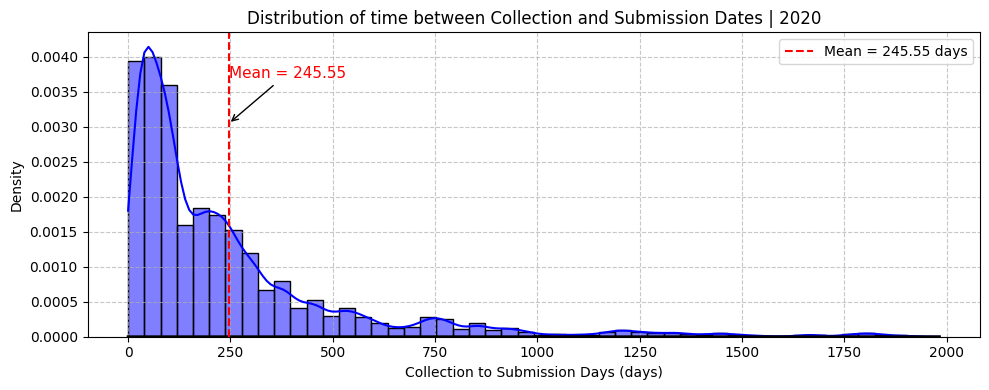

In [18]:
plt.figure(figsize=(10, 4))
sns.histplot(df["collection_to_submission_days"], bins=50, kde=True, color='blue', stat='density')
sns.lineplot(x=sorted(df["collection_to_submission_days"]), 
             y=np.full(df.shape[0], 0), color='black', linewidth=2)
mean_days = df["collection_to_submission_days"].mean()
plt.axvline(mean_days, color='red', linestyle='--', label=f"Mean = {mean_days:.2f} days")

# Place annotation above the mean line, at the top of the plot
ymax = plt.gca().get_ylim()[1]
plt.annotate(f"Mean = {mean_days:.2f}", xy=(mean_days, ymax*0.7), xytext=(mean_days+0.5, ymax*0.85),
             arrowprops=dict(facecolor='red', arrowstyle='->'), color='red', fontsize=11)

plt.xlabel("Collection to Submission Days (days)")
plt.title(f"Distribution of time between Collection and Submission Dates | {YEAR}")
plt.legend()
plt.tight_layout()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PLOTS_PATH, f"collection_to_submission_days_distribution_{YEAR}.png"), dpi=300)
plt.show()

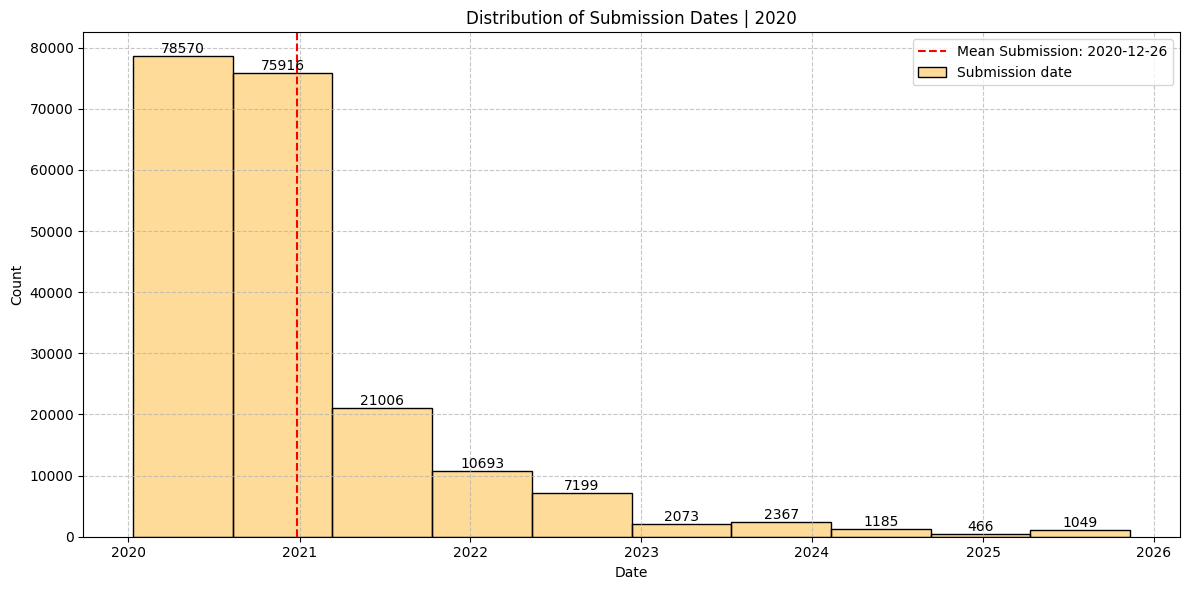

In [19]:
plt.figure(figsize=(12, 6))

# Plot histograms for submission dates
sns.histplot(df["Submission date"], bins=10, color="orange", label="Submission date", kde=False, alpha=0.4)

# Calculate means
mean_submission = df["Submission date"].mean()

# Plot mean lines
plt.axvline(mean_submission, color="red", linestyle="--", label=f"Mean Submission: {mean_submission.date()}")

# Annotate the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.xlabel("Date")
plt.ylabel("Count")
plt.title(f"Distribution of Submission Dates | {YEAR}")
plt.legend()
plt.tight_layout()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PLOTS_PATH, f"submission_dates_spread_{YEAR}.png"), dpi=300)
plt.show()

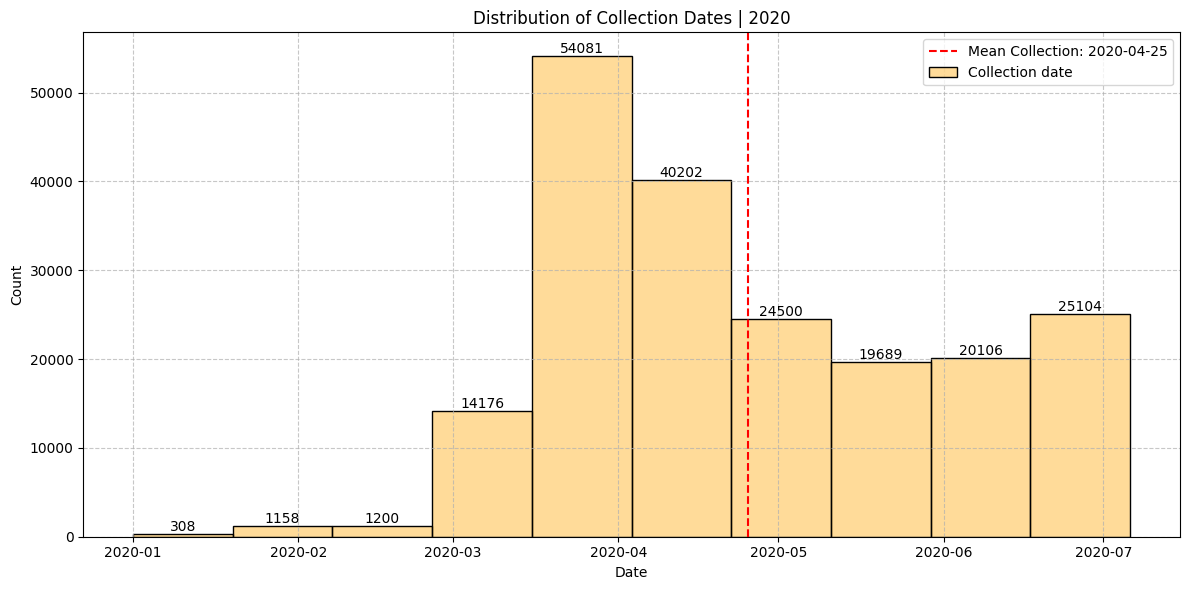

In [20]:
plt.figure(figsize=(12, 6))

# Plot histograms for collection dates
sns.histplot(df["Collection date"], bins=10, color="orange", label="Collection date", kde=False, alpha=0.4)

# Calculate means
mean_collection = df["Collection date"].mean()

# Plot mean lines
plt.axvline(mean_collection, color="red", linestyle="--", label=f"Mean Collection: {mean_collection.date()}")

# Annotate the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.xlabel("Date")
plt.ylabel("Count")
plt.title(f"Distribution of Collection Dates | {YEAR}")
plt.legend()
plt.tight_layout()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PLOTS_PATH, f"collection_dates_spread_{YEAR}.png"), dpi=300)
plt.show()

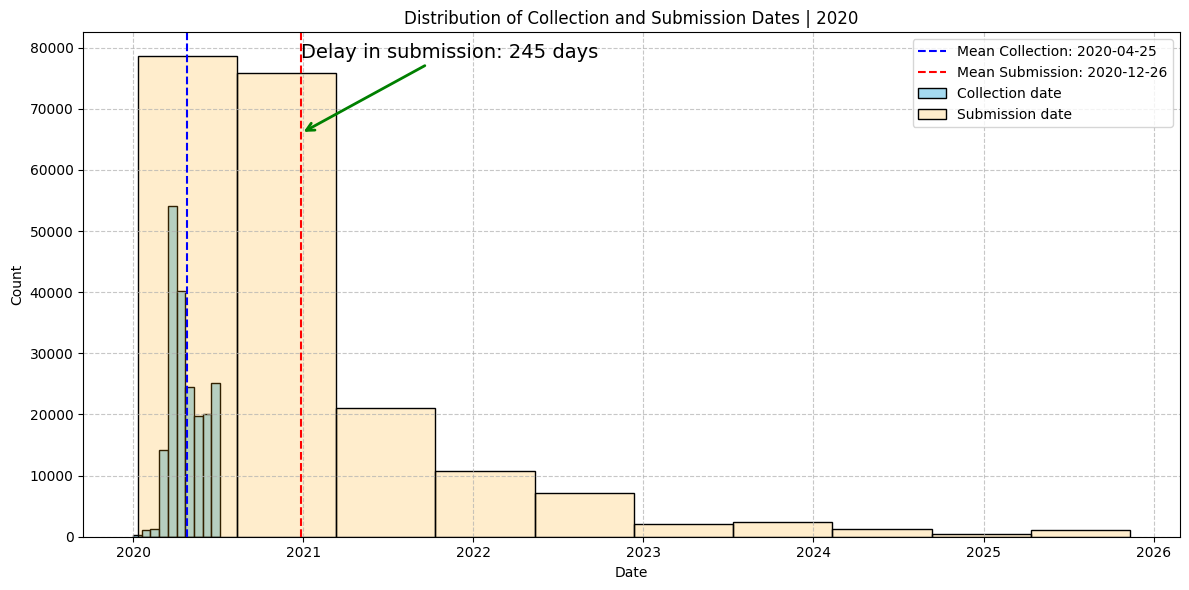

In [21]:
plt.figure(figsize=(12, 6))

# Plot histograms for collection and submission dates
sns.histplot(df["Collection date"], bins=10, color="skyblue", label="Collection date", kde=False)
sns.histplot(df["Submission date"], bins=10, color="orange", label="Submission date", kde=False, alpha=0.2)

# Calculate means
mean_collection = df["Collection date"].mean()
mean_submission = df["Submission date"].mean()

# Plot mean lines
plt.axvline(mean_collection, color="blue", linestyle="--", label=f"Mean Collection: {mean_collection.date()}")
plt.axvline(mean_submission, color="red", linestyle="--", label=f"Mean Submission: {mean_submission.date()}")

# Annotate lead time
lead_time = (mean_submission - mean_collection).days
plt.annotate(
    f"Delay in submission: {lead_time} days",
    xy=(mean_submission, plt.ylim()[1]*0.8),
    xytext=(mean_submission, plt.ylim()[1]*0.95),
    arrowprops=dict(facecolor='green', edgecolor='green', arrowstyle='->', lw=2),
    color="black",
    fontsize=14,
    ha='left'
)

plt.xlabel("Date")
plt.ylabel("Count")
plt.title(f"Distribution of Collection and Submission Dates | {YEAR}")
plt.legend()
plt.tight_layout()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PLOTS_PATH, f"collection_submission_dates_distribution_{YEAR}.png"), dpi=300)
plt.show()

In [22]:
df["Gender"].value_counts()

Gender
unknown    126740
Male        38933
Female      34391
49.0           17
unknowm        15
            ...  
64              1
9               1
13              1
62.0            1
23.0            1
Name: count, Length: 133, dtype: int64

In [23]:
df["Patient status"].value_counts()

Patient status
unknown                                     183281
Symptomatic                                   4192
Hospitalized                                  3642
Live                                          2700
Released                                      1839
                                             ...  
Rebased                                          1
Hopsitalized                                     1
Non-hospitalized, symptomps: sore throat         1
Suspected Re-infection                           1
Non-hospitalized, symptomps: cough               1
Name: count, Length: 134, dtype: int64

In [24]:
df["Patient age"].value_counts()

Patient age
unknown     128416
30            1250
35            1196
32            1184
55            1172
             ...  
0.2              1
51- 60           1
56 years         1
0-4              1
Unkown           1
Name: count, Length: 311, dtype: int64

In [25]:
df[~df["Gender"].isin(["Male", "Female", "unknown"])]

,Accession ID,Collection date,Submission date,Location,Gender,Patient status,Patient age,Additional location information,Last vaccinated,Additional host information,Clinical status,Hospitalization status,Severity,WHO category,collection_to_submission_days
7791,EPI_ISL_4405694,2020-01-01,2021-09-22,South America / Argentina / Buenos Aires / Exa...,3.0,unknown,Female,NaN,unknown,NaN,unknown,unknown,unknown,Unknown,630
55896,EPI_ISL_5944632,2020-03-18,2021-11-05,North America / USA / New York,66.0,Released,Male,NaN,unknown,NaN,recovered,yes,uninfected,Uninfected,597
55356,EPI_ISL_5944636,2020-03-19,2021-11-05,North America / USA / New York,57.0,Released,Male,NaN,unknown,NaN,recovered,yes,uninfected,Uninfected,596
169953,EPI_ISL_5944531,2020-03-25,2021-11-05,North America / USA / New York,69.0,Released,Male,NaN,unknown,NaN,recovered,yes,uninfected,Uninfected,590
187956,EPI_ISL_5944897,2020-03-27,2021-11-05,North America / USA / New York,76.0,Released,Female,NaN,unknown,NaN,recovered,yes,uninfected,Uninfected,588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199407,EPI_ISL_4220023,2020-07-06,2021-09-15,North America / Mexico / Mexico City,28,unknown,Male,NaN,unknown,NaN,unknown,unknown,unknown,Unknown,436
199406,EPI_ISL_4220025,2020-07-06,2021-09-15,North America / Mexico / Mexico City,57,unknown,Male,NaN,unknown,NaN,unknown,unknown,unknown,Unknown,436
199405,EPI_ISL_4220026,2020-07-06,2021-09-15,North America / Mexico / Mexico City,73,unknown,Male,NaN,unknown,NaN,unknown,unknown,unknown,Unknown,436
199404,EPI_ISL_4220027,2020-07-06,2021-09-15,North America / Mexico / Mexico City,51,unknown,Male,NaN,unknown,NaN,unknown,unknown,unknown,Unknown,436
